# Проверка метода DEER на корпусе WikiNER
#
**Конфигурация:** Kaggle GPU T4 (16 GB VRAM), модель Qwen2.5-7B-Instruct (FP16), эмбеддинги all-MiniLM-L6-v2.

In [1]:
!pip install -q transformers accelerate datasets sentence-transformers seqeval bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.8 MB/s eta 0:00:00:00:0100:01


In [2]:
import os, re, json, pickle, warnings
from collections import Counter, defaultdict
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm.auto import tqdm
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})
sns.set_style("whitegrid")

print(f"CUDA: {torch.cuda.is_available()}", 
      f"| GPU: {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "")

CUDA: True | GPU: Tesla T4


## 1. Загрузка LLM
Используем Qwen2.5-7B-Instruct — влезает на T4 в FP16 (~14 GB).

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, trust_remote_code=True, device_map="auto", torch_dtype=torch.float16
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Модель загружена | VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB")

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Модель загружена | VRAM: 6.7 GB


In [4]:
class LocalLLM:
    """Обёртка для генерации через chat-template."""
    def __init__(self, model, tokenizer):
        self.model, self.tokenizer = model, tokenizer
        self.total_calls = 0

    def generate(self, messages, max_new_tokens=512, temperature=0.01):
        text = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = self.tokenizer(text, return_tensors="pt", truncation=True, max_length=4096)
        inputs = {k: v.to(self.model.device) for k, v in inputs.items()}
        with torch.no_grad():
            out = self.model.generate(
                **inputs, max_new_tokens=max_new_tokens,
                do_sample=temperature > 0, temperature=max(temperature, 0.01),
                pad_token_id=self.tokenizer.pad_token_id
            )
        resp = self.tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        self.total_calls += 1
        return resp.strip()

    def safe_generate(self, messages, **kw):
        try:
            return self.generate(messages, **kw)
        except Exception as e:
            print(f"Ошибка: {e}")
            return '{"named entities": []}'

llm = LocalLLM(model, tokenizer)

# быстрый тест
resp = llm.generate([{"role": "user", "content": 'Say hi in JSON: {"msg":"..."}'}], max_new_tokens=30)
print(f"Тест: {resp[:100]}")

Тест: {"msg":"Hi there!"}


## 2. Гиперпараметры DEER

In [5]:
class Config:
    CONTEXT_WINDOW = 2      # ±2 токена вокруг сущности
    NUM_SHOTS = 8
    LAMBDA_1 = 1.0          # вес token-overlap
    LAMBDA_2 = 1.0          # вес cosine similarity
    W_ENTITY = 1.0
    W_CONTEXT = 1.0
    W_OTHER = 0.01
    W_UNSEEN = 1.0
    THETA_FN = 0.95         # порог для false-negative триггера
    BOUNDARY_K = 2
    MAX_TRAIN = 5000
    MAX_TEST = 100
    CACHE = "/kaggle/working/deer_cache"
    EMB_MODEL = "all-MiniLM-L6-v2"

cfg = Config()
os.makedirs(cfg.CACHE, exist_ok=True)

## 3. Данные — WikiNER (французский)
Берём `Jean-Baptiste/wikiner_fr`, делим 80/20, семплируем подмножества.

In [6]:
from datasets import load_dataset

raw = load_dataset("Jean-Baptiste/wikiner_fr")
tag_names = raw["train"].features["ner_tags"].feature.names  # ['O','LOC','PER','MISC','ORG']

def parse_example(ex):
    tokens = ex["tokens"]
    tags = [tag_names[t] for t in ex["ner_tags"]]
    # собираем сущности из последовательных одинаковых тегов
    entities, i = [], 0
    while i < len(tokens):
        if tags[i] != "O":
            etype, start = tags[i], i
            while i < len(tokens) and tags[i] == etype:
                i += 1
            entities.append({"name": " ".join(tokens[start:i]), "type": etype, "start": start, "end": i})
        else:
            i += 1
    return {"tokens": tokens, "entities": entities, "text": " ".join(tokens)}

all_parsed = [parse_example(ex) for ex in raw["train"]]
with_ent = [s for s in all_parsed if s["entities"]]

np.random.seed(42)
idx = np.random.permutation(len(with_ent))
split = int(len(with_ent) * 0.8)

train_pool = [with_ent[i] for i in idx[:split]]
test_pool = [with_ent[i] for i in idx[split:]]

train_data = [train_pool[i] for i in np.random.choice(len(train_pool), min(cfg.MAX_TRAIN, len(train_pool)), replace=False)]
test_data = [test_pool[i] for i in np.random.choice(len(test_pool), min(cfg.MAX_TEST, len(test_pool)), replace=False)]

print(f"Train: {len(train_data)} | Test: {len(test_data)}")
print(f"Пример: {train_data[0]['text'][:80]}...")
print(f"Сущности: {[(e['name'], e['type']) for e in train_data[0]['entities']]}")

README.md:   0%|          | 0.00/964 [00:00<?, ?B/s]

data/train-00000-of-00001-8a0e6775bf2770(…):   0%|          | 0.00/10.9M [00:00<?, ?B/s]

data/test-00000-of-00001-f042d39bd1dddf2(…):   0%|          | 0.00/1.20M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120682 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/13410 [00:00<?, ? examples/s]

Train: 5000 | Test: 100
Пример: Au Québec il s' agit de la langue des signes québécoise ....
Сущности: [('Québec', 'LOC')]


## 4. Шаг 0 — статистика токенов
Каждый токен классифицируется как entity / context (±2 слова) / other.
Считаем $P(t_e), P(t_c), P(t_o)$ и вес $W(t)$.

In [7]:
class TokenStatistics:
    def __init__(self, sentences, cw=2):
        self.ent_cnt, self.ctx_cnt, self.oth_cnt, self.tot_cnt = Counter(), Counter(), Counter(), Counter()
        self.entity_spans = defaultdict(list)
        self.context_spans = defaultdict(list)
        self.token_entity_examples = defaultdict(list)

        for sent in tqdm(sentences, desc="Сбор статистики"):
            tokens = sent["tokens"]
            n = len(tokens)
            roles = ["other"] * n
            ent_pos = set()
            for e in sent["entities"]:
                for p in range(e["start"], min(e["end"], n)):
                    roles[p] = "entity"; ent_pos.add(p)
            for p in list(ent_pos):
                for off in range(-cw, cw + 1):
                    cp = p + off
                    if 0 <= cp < n and cp not in ent_pos:
                        roles[cp] = "context"

            for i, tok in enumerate(tokens):
                t = tok.lower()
                self.tot_cnt[t] += 1
                {"entity": self.ent_cnt, "context": self.ctx_cnt, "other": self.oth_cnt}[roles[i]][t] += 1
                s, e = max(0, i-2), min(n, i+3)
                span = " ".join(tokens[s:e])
                if roles[i] == "entity":
                    self.entity_spans[t].append(span)
                elif roles[i] == "context":
                    self.context_spans[t].append(span)

            for ent in sent["entities"]:
                for p in range(ent["start"], min(ent["end"], n)):
                    self.token_entity_examples[tokens[p].lower()].append(
                        {"sentence": sent["text"], "entity": ent})

    def _p(self, cnt, tok):
        t = tok.lower()
        return cnt[t] / self.tot_cnt[t] if self.tot_cnt[t] else 0.0

    def p_entity(self, tok):  return self._p(self.ent_cnt, tok)
    def p_context(self, tok): return self._p(self.ctx_cnt, tok)
    def p_other(self, tok):   return self._p(self.oth_cnt, tok)
    def is_seen(self, tok):   return tok.lower() in self.tot_cnt

    def weight(self, tok):
        if not self.is_seen(tok):
            return cfg.W_UNSEEN
        return cfg.W_ENTITY * self.p_entity(tok) + cfg.W_CONTEXT * self.p_context(tok) + cfg.W_OTHER * self.p_other(tok)

ts = TokenStatistics(train_data, cfg.CONTEXT_WINDOW)
print(f"Словарь: {len(ts.tot_cnt)} | P(ent)>0.95: {sum(1 for t in ts.tot_cnt if ts.p_entity(t) > 0.95)}")

Сбор статистики:   0%|          | 0/5000 [00:00<?, ?it/s]

Словарь: 19694 | P(ent)>0.95: 5557


## 5. Эмбеддинги токенов (локальные)
Считаем взвешенный вектор предложения: $v_s = \sum W(t) \cdot v_t$

In [8]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer(cfg.EMB_MODEL)
EDIM = embed_model.get_sentence_embedding_dimension()

all_toks = sorted({t.lower() for s in train_data + test_data for t in s["tokens"]})
tok_emb_matrix = embed_model.encode(all_toks, show_progress_bar=True, batch_size=256)
tok_emb_map = dict(zip(all_toks, tok_emb_matrix))

def weighted_sent_emb(tokens):
    vec = sum(ts.weight(t) * tok_emb_map[t.lower()] for t in tokens if t.lower() in tok_emb_map)
    if isinstance(vec, (int, float)):
        return np.zeros(EDIM)
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec

train_embs = np.array([weighted_sent_emb(s["tokens"]) for s in tqdm(train_data, desc="Векторы train")])
print(f"Матрица train: {train_embs.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/78 [00:00<?, ?it/s]

Векторы train:   0%|          | 0/5000 [00:00<?, ?it/s]

Матрица train: (5000, 384)


## 6. Шаг 1 — DEER Retrieval + бейзлайны
Гибридный скоринг: $S = \lambda_1 S_{token} + \lambda_2 S_{embed}$

In [9]:
class DEERRetriever:
    def __init__(self, train_data, ts, train_embs):
        self.train_data, self.ts, self.train_embs = train_data, ts, train_embs
        self.train_tok_sets = [{t.lower() for t in s["tokens"]} for s in train_data]

    def retrieve(self, test_sent, k=8):
        test_tokens = test_sent["tokens"]
        test_emb = weighted_sent_emb(test_tokens)
        scores = []
        for i in range(len(self.train_data)):
            s_tok = sum(self.ts.weight(t) for t in test_tokens if t.lower() in self.train_tok_sets[i])
            s_emb = float(np.dot(test_emb, self.train_embs[i]))
            scores.append((i, cfg.LAMBDA_1 * s_tok + cfg.LAMBDA_2 * s_emb))
        scores.sort(key=lambda x: x[1], reverse=True)
        return [(self.train_data[i], sc) for i, sc in scores[:k]]

class RandomRetriever:
    def __init__(self, data): self.data = data
    def retrieve(self, sent, k=8):
        return [(self.data[i], 0) for i in np.random.choice(len(self.data), k, replace=False)]

class SentEmbRetriever:
    def __init__(self, train_data, embed_model):
        self.train_data = train_data
        self.embs = embed_model.encode([s["text"] for s in train_data], show_progress_bar=True, batch_size=256)
    def retrieve(self, sent, k=8):
        qe = embed_model.encode([sent["text"]])[0].reshape(1, -1)
        sims = cosine_similarity(qe, self.embs)[0]
        top = np.argsort(sims)[-k:][::-1]
        return [(self.train_data[i], sims[i]) for i in top]

deer_ret = DEERRetriever(train_data, ts, train_embs)
rand_ret = RandomRetriever(train_data)
sent_ret = SentEmbRetriever(train_data, embed_model)

# проверка
ex = test_data[0]
print(f"Запрос: {ex['text'][:70]}...")
for i, (s, sc) in enumerate(deer_ret.retrieve(ex, 3)):
    print(f"  #{i+1} ({sc:.1f}): {s['text'][:55]}... | {[(e['name'],e['type']) for e in s['entities']]}")

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Запрос: A l' inverse du Tour de France , il n' y a pas de différenciation d' a...
  #1 (6.9): Dans les années 1970 , en analysant au carbone 14 des c... | [('mer Noire', 'LOC'), ('mer Noire', 'LOC'), ('lac Pontique', 'LOC')]
  #2 (6.9): En 2008 , l' INSERM a conclu d' une revue de la littéra... | [('INSERM', 'ORG')]
  #3 (6.9): Par ailleurs , la France qui a justifié son programme n... | [('la France', 'LOC')]


## 7. Промпты и парсинг JSON

In [10]:
SYSTEM_PROMPT = (
    "You are a Named Entity Recognition system. "
    "Extract entities of types: PER, ORG, LOC, MISC. "
    'Output ONLY valid JSON: {"named entities": [{"name": "...", "type": "..."}]}. '
    'If none: {"named entities": []}. No explanation.'
)

def format_examples(examples):
    parts = []
    for ex in examples:
        ents = [{"name": e["name"], "type": e["type"]} for e in ex["entities"]]
        parts.append(f'Sentence: {ex["text"]}\nOutput: {json.dumps({"named entities": ents})}')
    return "\n\n".join(parts)

def build_ner_prompt(test_sent, examples):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Examples:\n\n{format_examples(examples)}\n\nExtract entities from:\nSentence: {test_sent['text']}\nOutput:"}
    ]

def build_reflection_prompt(test_sent, current_ents, analysis):
    return [
        {"role": "system", "content": "You are an NER expert doing error correction. Based on evidence, update entities if needed. Output ONLY JSON."},
        {"role": "user", "content": f"Sentence: {test_sent['text']}\nCurrent: {json.dumps({'named entities': current_ents})}\n\nEvidence:\n{analysis}\n\nProvide corrected FULL entity list as JSON only:"}
    ]

def parse_ner_response(text):
    if "```json" in text:
        text = text.split("```json")[1].split("```")[0]
    elif "```" in text:
        parts = text.split("```")
        if len(parts) >= 3: text = parts[1]
    text = text.strip()
    try:
        data = json.loads(text)
        if isinstance(data, dict):
            for key in ["named entities", "named_entities", "entities"]:
                if key in data and isinstance(data[key], list):
                    return [e for e in data[key] if isinstance(e, dict) and "name" in e and "type" in e]
        if isinstance(data, list):
            return [e for e in data if isinstance(e, dict) and "name" in e and "type" in e]
    except: pass
    # фоллбэк — ищем JSON в тексте
    for m in re.finditer(r'\{[^{}]*"named[_ ]entities"[^{}]*\[.*?\][^{}]*\}', text, re.DOTALL):
        try:
            d = json.loads(m.group())
            return d.get("named entities", d.get("named_entities", []))
        except: pass
    return []

## 8. Шаг 2 — рефлексия ошибок
Три типа триггеров: unseen tokens, false negatives ($P(t_e) > 0.95$), boundary issues.

In [11]:
class Reflector:
    def __init__(self, ts): self.ts = ts

    def _covered(self, tokens, entities):
        covered = set()
        for ent in entities:
            et = ent.get("name", "").split()
            if not et: continue
            for s in range(len(tokens) - len(et) + 1):
                if all(tokens[s+j].lower() == et[j].lower() for j in range(len(et))):
                    covered.update(range(s, s + len(et))); break
        return covered

    def check_unseen(self, sent, entities):
        tokens, covered = sent["tokens"], self._covered(sent["tokens"], entities)
        triggers = []
        for i, tok in enumerate(tokens):
            if i in covered or self.ts.is_seen(tok): continue
            evidence = [f"'{tokens[i+off]}'(P_ctx={self.ts.p_context(tokens[i+off]):.2f})"
                        for off in [-2,-1,1,2]
                        if 0 <= i+off < len(tokens) and self.ts.is_seen(tokens[i+off]) and self.ts.p_context(tokens[i+off]) > 0.3]
            if evidence:
                spans = []
                for off in [-1, 1]:
                    ci = i + off
                    if 0 <= ci < len(tokens):
                        spans.extend(self.ts.context_spans.get(tokens[ci].lower(), [])[:2])
                triggers.append((tok, evidence, spans[:3]))
        if not triggers: return None
        lines = ["UNSEEN TOKENS:"]
        for tok, ev, spans in triggers[:3]:
            lines.append(f"- '{tok}' unseen, context: {', '.join(ev)}")
            if spans: lines.append(f"  Examples: {spans}")
        lines.append("Should these be entities?")
        return "\n".join(lines)

    def check_false_negatives(self, sent, entities):
        tokens, covered = sent["tokens"], self._covered(sent["tokens"], entities)
        triggers = []
        for i, tok in enumerate(tokens):
            if i in covered or not self.ts.is_seen(tok): continue
            pe = self.ts.p_entity(tok)
            if pe >= cfg.THETA_FN:
                exs = self.ts.token_entity_examples.get(tok.lower(), [])[:2]
                triggers.append((tok, pe, self.ts.ent_cnt[tok.lower()], self.ts.tot_cnt[tok.lower()], exs))
        if not triggers: return None
        lines = ["FALSE NEGATIVES:"]
        for tok, pe, ec, tc, exs in triggers[:3]:
            lines.append(f"- '{tok}' NOT marked, but entity {ec}/{tc} times (P={pe:.2f})")
            if exs: lines.append(f"  E.g.: '{exs[0]['entity']['name']}' ({exs[0]['entity']['type']})")
        lines.append("Should these be entities?")
        return "\n".join(lines)

    def check_boundaries(self, sent, entities):
        tokens = sent["tokens"]
        triggers = []
        for ent in entities:
            et = ent.get("name", "").split()
            if not et: continue
            start = None
            for s in range(len(tokens) - len(et) + 1):
                if all(tokens[s+j].lower() == et[j].lower() for j in range(len(et))):
                    start = s; break
            if start is None: continue
            end = start + len(et)
            issues = []
            for p in [start, end-1]:
                if self.ts.is_seen(tokens[p]) and self.ts.p_other(tokens[p]) > 0.85:
                    issues.append(f"'{tokens[p]}' inside but usually Other ({self.ts.p_other(tokens[p]):.0%})")
            for p in [start-1, end]:
                if 0 <= p < len(tokens) and self.ts.is_seen(tokens[p]) and self.ts.p_entity(tokens[p]) > 0.7:
                    issues.append(f"'{tokens[p]}' adjacent, often entity ({self.ts.p_entity(tokens[p]):.0%})")
            if issues: triggers.append((ent, issues))
        if not triggers: return None
        lines = ["BOUNDARY CHECK:"]
        for ent, issues in triggers[:3]:
            lines.append(f"- '{ent['name']}' ({ent['type']}): {'; '.join(issues)}")
        lines.append("Adjust if needed.")
        return "\n".join(lines)

reflector = Reflector(ts)

## 9. Метрики (entity-level P/R/F1)

In [12]:
def norm_ent(e):
    name = e.get("name","").strip().lower()
    tp = e.get("type","").strip().upper()
    tp = {"PERSON":"PER","LOCATION":"LOC","ORGANIZATION":"ORG","MISCELLANEOUS":"MISC"}.get(tp, tp)
    return (name, tp)

def calc_metrics(results, key="final_prediction"):
    tp = fp = fn = 0
    type_c = defaultdict(lambda: {"tp":0,"fp":0,"fn":0})
    for r in results:
        gold = {norm_ent(e) for e in r["gold_entities"]}
        pred = {norm_ent(e) for e in r.get(key, [])}
        matched = gold & pred
        tp += len(matched); fp += len(pred - gold); fn += len(gold - pred)
        for _, et in gold | pred:
            g = {e for e in gold if e[1]==et}; p = {e for e in pred if e[1]==et}
            type_c[et]["tp"] += len(g & p); type_c[et]["fp"] += len(p - g); type_c[et]["fn"] += len(g - p)
    prec = tp/(tp+fp) if tp+fp else 0
    rec = tp/(tp+fn) if tp+fn else 0
    f1 = 2*prec*rec/(prec+rec) if prec+rec else 0
    per_type = {}
    for et, c in type_c.items():
        p = c["tp"]/(c["tp"]+c["fp"]) if c["tp"]+c["fp"] else 0
        r2 = c["tp"]/(c["tp"]+c["fn"]) if c["tp"]+c["fn"] else 0
        per_type[et] = {"precision": p, "recall": r2, "f1": 2*p*r2/(p+r2) if p+r2 else 0}
    return {"precision": prec, "recall": rec, "f1": f1, "tp": tp, "fp": fp, "fn": fn, "per_type": per_type}

## 10. Основной цикл экспериментов

In [13]:
def run_experiment(name, retriever, test_data, llm, use_reflection=False):
    print(f"{len(test_data)} примеров | refl={use_reflection}\n")
    results = []
    for i, test_sent in enumerate(tqdm(test_data, desc=name)):
        examples = [s for s, _ in retriever.retrieve(test_sent, k=cfg.NUM_SHOTS)]
        resp = llm.safe_generate(build_ner_prompt(test_sent, examples), max_new_tokens=256)
        initial = parse_ner_response(resp)
        result = {"text": test_sent["text"], "tokens": test_sent["tokens"],
                  "gold_entities": test_sent["entities"],
                  "initial_prediction": initial, "final_prediction": list(initial),
                  "reflection_triggers": [], "raw_response": resp}

        if use_reflection:
            current = list(initial)
            for cname, cfn in [("unseen", reflector.check_unseen),
                               ("false_negative", reflector.check_false_negatives),
                               ("boundary", reflector.check_boundaries)]:
                analysis = cfn(test_sent, current)
                if analysis:
                    result["reflection_triggers"].append(cname)
                    r2 = llm.safe_generate(build_reflection_prompt(test_sent, current, analysis), max_new_tokens=256)
                    updated = parse_ner_response(r2)
                    if updated: current = updated
            result["final_prediction"] = current

        results.append(result)
        if (i+1) % 20 == 0:
            m = calc_metrics(results)
            print(f"  [{i+1}/{len(test_data)}] P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f}")
    return results

In [14]:
res_deer_full = run_experiment("DEER Full",      deer_ret, test_data, llm, use_reflection=True)
res_deer_noref = run_experiment("DEER Retrieval", deer_ret, test_data, llm, use_reflection=False)
res_sent = run_experiment("Sent-Emb kNN",        sent_ret, test_data, llm, use_reflection=False)
res_rand = run_experiment("Random",              rand_ret, test_data, llm, use_reflection=False)

with open(os.path.join(cfg.CACHE, "all_results.pkl"), "wb") as f:
    pickle.dump({"deer_full": res_deer_full, "deer_noref": res_deer_noref,
                 "sentemb": res_sent, "random": res_rand}, f)
print(f"\nВсего вызовов LLM: {llm.total_calls}")

100 примеров | refl=True



DEER Full:   0%|          | 0/100 [00:00<?, ?it/s]

  [20/100] P=0.481 R=0.703 F1=0.571
  [40/100] P=0.500 R=0.701 F1=0.584
  [60/100] P=0.548 R=0.726 F1=0.625
  [80/100] P=0.574 R=0.727 F1=0.641
  [100/100] P=0.557 R=0.733 F1=0.633
100 примеров | refl=False



DEER Retrieval:   0%|          | 0/100 [00:00<?, ?it/s]

  [20/100] P=0.750 R=0.730 F1=0.740
  [40/100] P=0.707 R=0.753 F1=0.730
  [60/100] P=0.718 R=0.761 F1=0.739
  [80/100] P=0.743 R=0.753 F1=0.748
  [100/100] P=0.737 R=0.761 F1=0.749
100 примеров | refl=False



Sent-Emb kNN:   0%|          | 0/100 [00:00<?, ?it/s]

  [20/100] P=0.659 R=0.730 F1=0.692
  [40/100] P=0.667 R=0.753 F1=0.707
  [60/100] P=0.677 R=0.752 F1=0.713
  [80/100] P=0.694 R=0.740 F1=0.716
  [100/100] P=0.698 R=0.744 F1=0.720
100 примеров | refl=False



Random:   0%|          | 0/100 [00:00<?, ?it/s]

  [20/100] P=0.606 R=0.541 F1=0.571
  [40/100] P=0.613 R=0.597 F1=0.605
  [60/100] P=0.673 R=0.650 F1=0.661
  [80/100] P=0.693 R=0.633 F1=0.662
  [100/100] P=0.674 R=0.644 F1=0.659

Всего вызовов LLM: 495


## 11. Результаты

In [15]:
m_full = calc_metrics(res_deer_full)
m_noref = calc_metrics(res_deer_noref)
m_init = calc_metrics(res_deer_full, "initial_prediction")
m_sent = calc_metrics(res_sent)
m_rand = calc_metrics(res_rand)

table = pd.DataFrame({
    "Method": ["DEER Full", "DEER Retrieval", "DEER (pre-refl.)", "Sent-Emb kNN", "Random"],
    "Precision": [m["precision"] for m in [m_full, m_noref, m_init, m_sent, m_rand]],
    "Recall":    [m["recall"]    for m in [m_full, m_noref, m_init, m_sent, m_rand]],
    "F1":        [m["f1"]        for m in [m_full, m_noref, m_init, m_sent, m_rand]],
})
print(table.to_string(index=False, float_format="%.3f"))

print("\nПо типам (DEER Full):")
for et in sorted(m_full["per_type"]):
    m = m_full["per_type"][et]
    print(f"  {et:6s}: P={m['precision']:.3f}  R={m['recall']:.3f}  F1={m['f1']:.3f}")

          Method  Precision  Recall    F1
       DEER Full      0.557   0.733 0.633
  DEER Retrieval      0.737   0.761 0.749
DEER (pre-refl.)      0.737   0.761 0.749
    Sent-Emb kNN      0.698   0.744 0.720
          Random      0.674   0.644 0.659

По типам (DEER Full):
  AST   : P=0.000  R=0.000  F1=0.000
  DATE  : P=0.000  R=0.000  F1=0.000
  EVENT : P=0.000  R=0.000  F1=0.000
  GPE   : P=0.000  R=0.000  F1=0.000
  LOC   : P=0.676  R=0.753  F1=0.713
  MISC  : P=0.248  R=0.431  F1=0.314
  NUM   : P=0.000  R=0.000  F1=0.000
  O     : P=0.000  R=0.000  F1=0.000
  OBJ   : P=0.000  R=0.000  F1=0.000
  ORG   : P=0.351  R=0.650  F1=0.456
  OTHER : P=0.000  R=0.000  F1=0.000
  PEOPLE: P=0.000  R=0.000  F1=0.000
  PER   : P=0.762  R=0.965  F1=0.852
  PRODUCT: P=0.000  R=0.000  F1=0.000
  STAR  : P=0.000  R=0.000  F1=0.000
  STATE : P=0.000  R=0.000  F1=0.000
  VERB  : P=0.000  R=0.000  F1=0.000


## 12. Визуализация

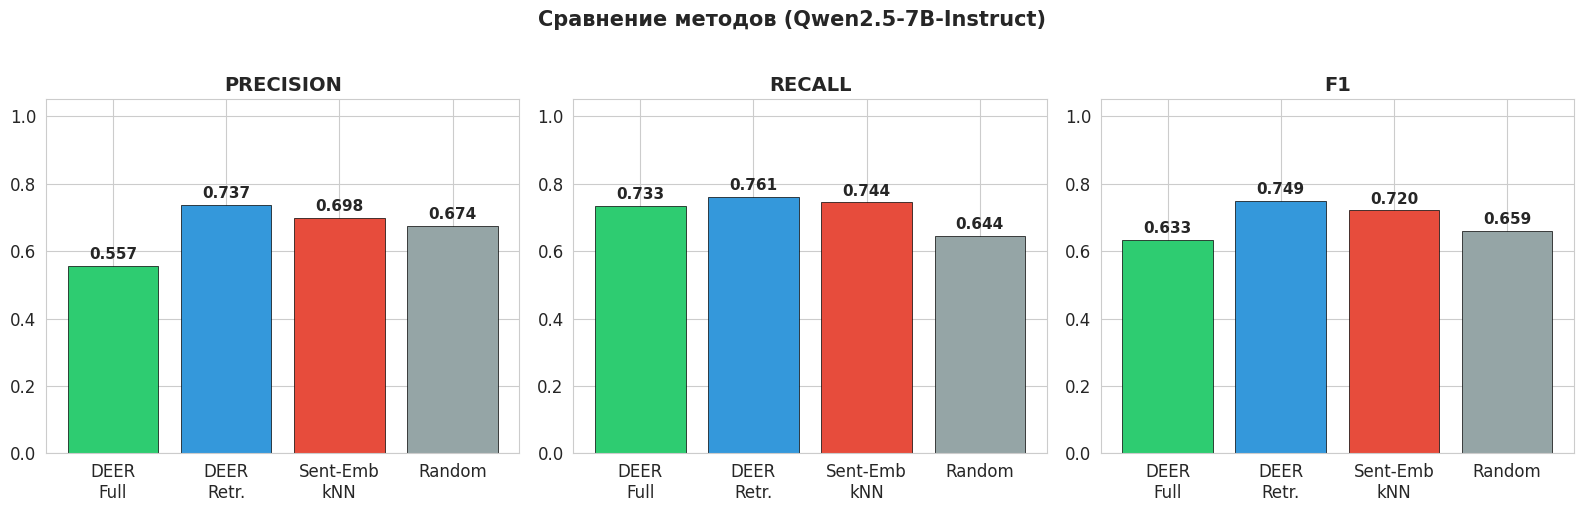

In [16]:
# --- График 1: Сравнение методов ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
methods = ["DEER\nFull", "DEER\nRetr.", "Sent-Emb\nkNN", "Random"]
colors = ["#2ecc71", "#3498db", "#e74c3c", "#95a5a6"]
all_m = [m_full, m_noref, m_sent, m_rand]

for ax, metric in zip(axes, ["precision", "recall", "f1"]):
    vals = [m[metric] for m in all_m]
    bars = ax.bar(methods, vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(metric.upper(), fontsize=14, fontweight="bold")
    ax.set_ylim(0, 1.05)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.suptitle(f"Сравнение методов ({MODEL_NAME.split('/')[-1]})", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.savefig(f"{cfg.CACHE}/01_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

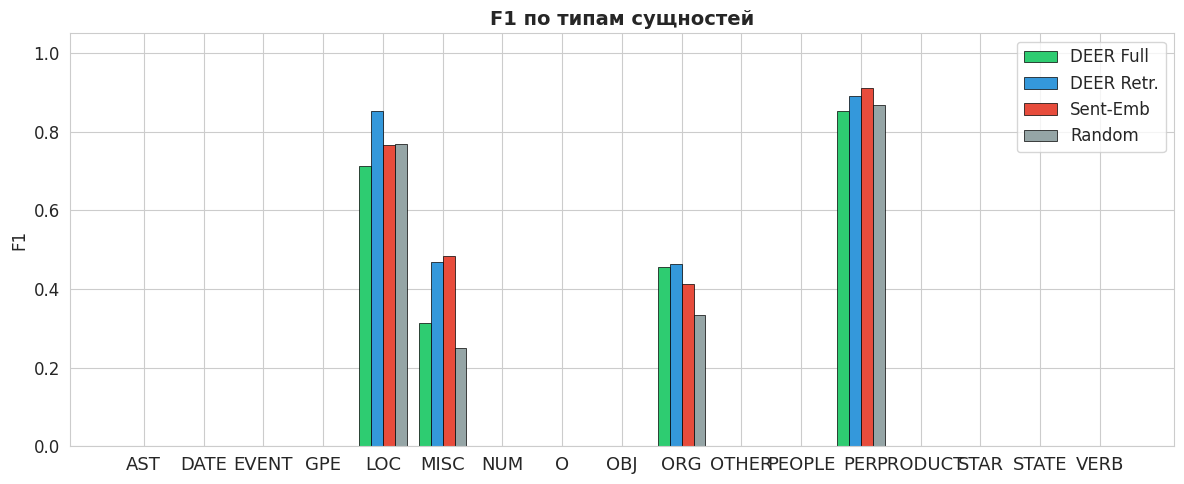

In [17]:
# --- График 2: F1 по типам ---
fig, ax = plt.subplots(figsize=(12, 5))
etypes = sorted(set(list(m_full["per_type"]) + list(m_sent["per_type"])))
x, w = np.arange(len(etypes)), 0.2
for i, (m, label, col) in enumerate([(m_full,"DEER Full","#2ecc71"), (m_noref,"DEER Retr.","#3498db"),
                                      (m_sent,"Sent-Emb","#e74c3c"), (m_rand,"Random","#95a5a6")]):
    ax.bar(x + i*w, [m["per_type"].get(et,{}).get("f1",0) for et in etypes], w, label=label, color=col, edgecolor="black", linewidth=0.5)
ax.set_xticks(x + 1.5*w); ax.set_xticklabels(etypes, fontsize=13)
ax.set_ylabel("F1"); ax.set_title("F1 по типам сущностей", fontsize=14, fontweight="bold")
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.savefig(f"{cfg.CACHE}/02_by_type.png", dpi=150, bbox_inches="tight"); plt.show()

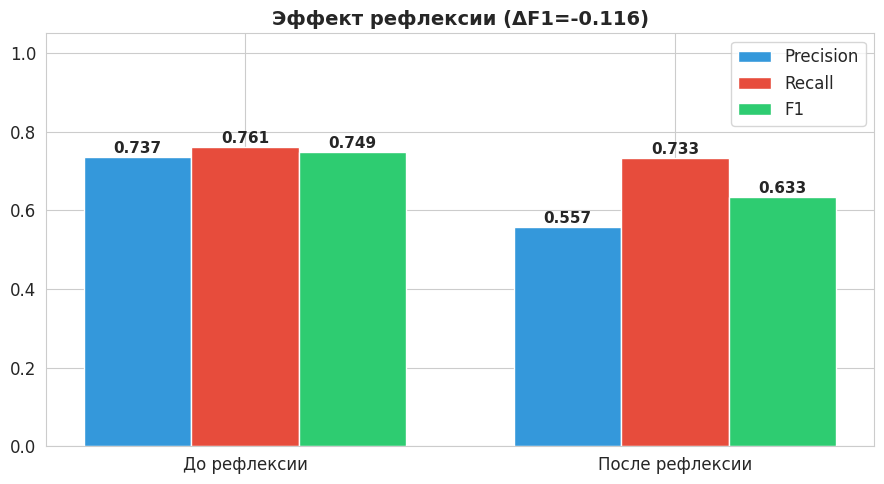

In [18]:
# --- График 3: Эффект рефлексии ---
fig, ax = plt.subplots(figsize=(9, 5))
x, w = np.arange(2), 0.25
for i, (metric, col, label) in enumerate([("precision","#3498db","Precision"),("recall","#e74c3c","Recall"),("f1","#2ecc71","F1")]):
    vals = [m_init[metric], m_full[metric]]
    bars = ax.bar(x + (i-1)*w, vals, w, label=label, color=col)
    for b in bars: ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.3f}", ha="center", fontsize=11, fontweight="bold")
delta = m_full["f1"] - m_init["f1"]
ax.set_title(f"Эффект рефлексии (ΔF1={delta:+.3f})", fontsize=14, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(["До рефлексии", "После рефлексии"], fontsize=12)
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.savefig(f"{cfg.CACHE}/03_reflection.png", dpi=150, bbox_inches="tight"); plt.show()

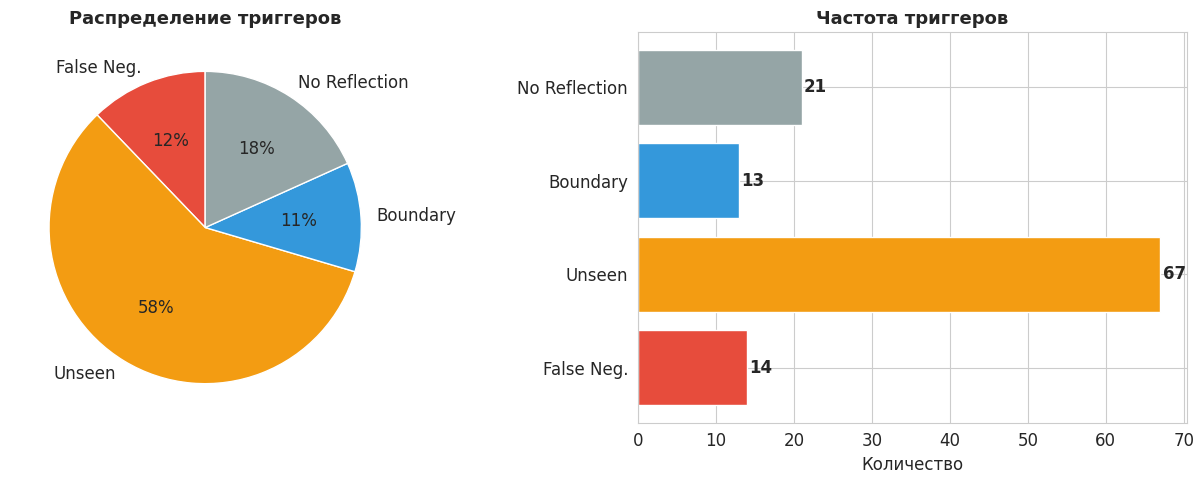

In [19]:
# --- График 4: Триггеры рефлексии ---
trig_cnt = Counter()
for r in res_deer_full:
    for t in r["reflection_triggers"]: trig_cnt[t] += 1
trig_cnt["none"] = sum(1 for r in res_deer_full if not r["reflection_triggers"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
lmap = {"unseen":"Unseen","false_negative":"False Neg.","boundary":"Boundary","none":"No Reflection"}
labs = [lmap.get(k,k) for k in trig_cnt]; sizes = list(trig_cnt.values())
cols4 = ["#e74c3c","#f39c12","#3498db","#95a5a6"][:len(labs)]
ax1.pie(sizes, labels=labs, autopct="%1.0f%%", colors=cols4, startangle=90)
ax1.set_title("Распределение триггеров", fontsize=13, fontweight="bold")
ax2.barh(labs, sizes, color=cols4)
ax2.set_xlabel("Количество"); ax2.set_title("Частота триггеров", fontsize=13, fontweight="bold")
for i,v in enumerate(sizes): ax2.text(v+0.3, i, str(v), va="center", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{cfg.CACHE}/04_triggers.png", dpi=150, bbox_inches="tight"); plt.show()

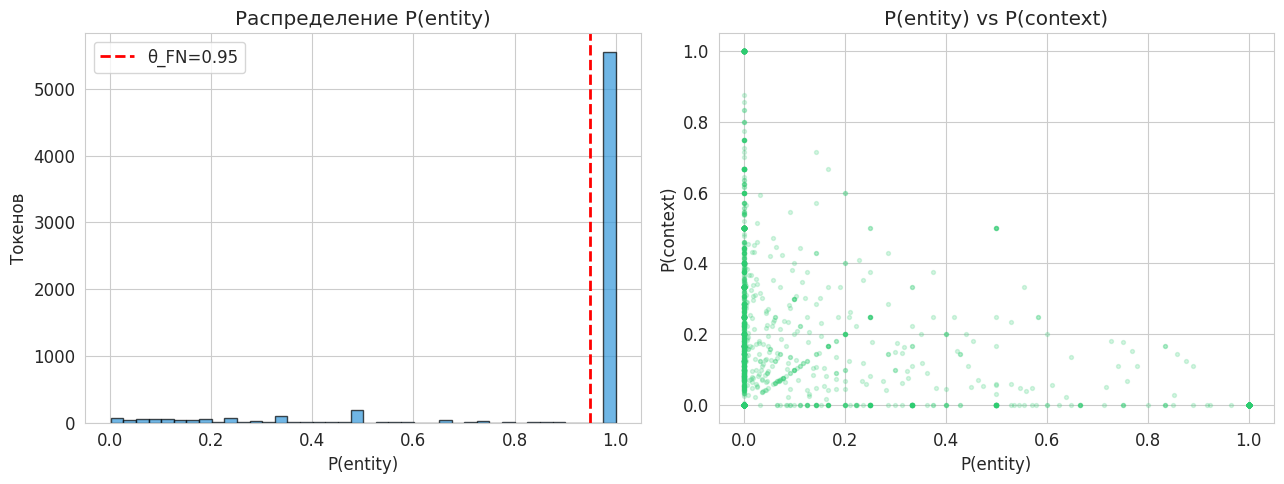

In [20]:
# --- График 5: Распределение P(entity) и scatter ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pe_vals = [ts.p_entity(t) for t in ts.tot_cnt if ts.p_entity(t) > 0]
axes[0].hist(pe_vals, bins=40, color="#3498db", edgecolor="black", alpha=0.7)
axes[0].axvline(x=cfg.THETA_FN, color="red", linestyle="--", linewidth=2, label=f"θ_FN={cfg.THETA_FN}")
axes[0].set_xlabel("P(entity)"); axes[0].set_ylabel("Токенов"); axes[0].set_title("Распределение P(entity)"); axes[0].legend()

sample = list(ts.tot_cnt.keys())[:3000]
axes[1].scatter([ts.p_entity(t) for t in sample], [ts.p_context(t) for t in sample], alpha=0.2, s=8, c="#2ecc71")
axes[1].set_xlabel("P(entity)"); axes[1].set_ylabel("P(context)"); axes[1].set_title("P(entity) vs P(context)")
plt.tight_layout(); plt.savefig(f"{cfg.CACHE}/05_token_stats.png", dpi=150, bbox_inches="tight"); plt.show()

## 13. Примеры предсказаний

In [22]:
for i, r in enumerate(res_deer_full[:8]):
    gold = [(e["name"], e["type"]) for e in r["gold_entities"]]
    final = [(e["name"], e["type"]) for e in r["final_prediction"]]
    g_n = {norm_ent(e) for e in r["gold_entities"]}
    f_n = {norm_ent(e) for e in r["final_prediction"]}
    st = "OK" if g_n == f_n else ("PARTIAL" if g_n & f_n else "MISS")
    print(f"\n#{i+1} [{st}] {r['text'][:85]}...")
    print(f"  Gold:  {gold}")
    print(f"  Pred:  {final}")
    if r["reflection_triggers"]: print(f"  Refl:  {r['reflection_triggers']}")


#1 [MISS] A l' inverse du Tour de France , il n' y a pas de différenciation d' attribution des ...
  Gold:  [('Tour de France', 'MISC')]
  Pred:  []
  Refl:  ['false_negative']

#2 [PARTIAL] Bologhine avait toutes les villes du Maghreb , il avait pour ordre de tuer tous les Z...
  Gold:  [('Bologhine', 'LOC'), ('Maghreb', 'LOC'), ('Zénètes', 'MISC'), ('Berbères', 'MISC')]
  Pred:  [('Bologhine', 'PER'), ('Maghreb', 'LOC'), ('Zénètes', 'PER'), ('Berbères', 'PER')]
  Refl:  ['unseen']

#3 [MISS] Dans l' ordre du zodiaque , la constellation se situe entre les Poissons à l' ouest e...
  Gold:  [('Poissons', 'LOC'), ('Taureau', 'LOC')]
  Pred:  [('Poissons', 'AST'), ('Taureau', 'AST')]
  Refl:  ['boundary']

#4 [OK] Elle contient l' environnement Classic , qui permet de faire fonctionner les applicat...
  Gold:  [('Classic', 'MISC'), ('Mac OS', 'MISC')]
  Pred:  [('Mac OS', 'MISC'), ('Classic', 'MISC')]
  Refl:  ['false_negative']

#5 [PARTIAL] Pour s' assurer de la neutralité du roi de To

## 14. Выводы

Идея DEER - token-level взвешенный retrieval - в принципе работает. Подбор примеров через статистику ролей токенов и гибридную метрику (точное совпадение + взвешенные эмбеддинги) дал F1=0.749, обойдя стандартный sentence-embedding поиск (F1=0.720, +2.9%) и случайную выборку (F1=0.659, +9.0%).

Однако механизм рефлексии ошибок, который в оригинальной статье давал прирост на GPT-4o, на 7B-модели ухудшил результат с F1=0.749 до 0.633 (−11.6%). Модель не справляется с цепочкой рассуждений: вместо точечных исправлений она галлюцинирует несуществующие типы сущностей (AST, STATE, OBJ) и добавляет ложные срабатывания, роняя precision с 0.737 до 0.557. 

Практический вывод: DEER Retrieval - возможно иногда рабочий способ улучшить ICL для NER даже на небольших моделях. Рефлексию стоит использовать только, если llm достаточно умная.




